# Cross-species D1R modulation of a visual fixation microcircuit model

An exercise in translational computational neuroscience through cross-species mechanistic modeling of cognition, featuring a spiking neural network model of sustained attention and response inhibition.

The modeling involves modulating the firing threshold of PV neurons based on differences in cell-type-specific PV-D1R co-expression between marmosets and macaques in the context of a visual fixation task.



Scripts to reproduce plots in Figure 7B-C in:

Mary Kate P. Joyce*, Tsvetoslav G. Ivanov*, Fenna M. Krienen, Jude F. Mitchell, Shaojie Ma, Wataru Inoue, Anirvan S. Nandy, Dibyadeep Datta, Alvaro Duque, Jon I. Arellano, Rahul Gupta, Guillermo Gonzalez-Burgos, David A. Lewis, Nenad Sestan, Steven A. McCarroll, Julio Martinez-Trujillo, Seán Froudist-Walsh+, Amy F. T. Arnsten+. "Higher dopamine D1 receptor expression in prefrontal parvalbumin neurons underlies higher distractibility in marmosets versus macaques." Communications Biology 8, 974 (2025). https://doi.org/10.1038/s42003-025-08297-0

*These authors contributed equally; +These authors jointly supervised the work

Notebook is variant form of:

Ivanov, T. G. (2025). Higher dopamine D1 receptor expression in prefrontal parvalbumin neurons underlies higher distractibility in marmosets versus macaques. Zenodo. https://doi.org/10.5281/zenodo.15380623

## 1. Install dependencies

In [1]:
%%capture
!pip install brian2 scipy matplotlib

## 2. Configure output directory

In [2]:
# To generate plots, you would need to change the directories based on your local directory structure!

from pathlib import Path

OUTPUT_DIR = Path("/content/vis_fix_model_res")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "marm-mac").mkdir(parents=True, exist_ok=True)

print(f"Notebook outputs will be written to {OUTPUT_DIR}")

Notebook outputs will be written to /content/vis_fix_model_res


## 3. Import packages and define model architecture and stimulus parameters

In [3]:
import numpy
import math
import brian2 as b2
from scipy.special import erf
from numpy.fft import rfft, irfft
from brian2 import NeuronGroup, Synapses, PoissonInput, network_operation
from brian2.monitors import SpikeMonitor
from brian2 import start_scope

# Set random seed for reproducible distractor sequences and initial membrane voltages.
numpy.random.seed(12345)

# Colab-compatible Brian2 setting. This avoids requiring a C++ compiler in the notebook runtime.
b2.prefs.codegen.target = "numpy"

# Network population sizes
N_excitatory = 2048
N_inhibitory = 512
N_fix_excitatory = 256
N_fix_inhibitory_per_pop = 32

# External Poisson input
N_extern_poisson = 1000
poisson_firing_rate = 1.80 * b2.Hz

# Connectivity profile parameters
sigma_weight_profile_E2E = 14.4
Jpos_excit2excit = 2.1

sigma_weight_profile_I2E = 14.4
Jpos_inhib2excit = 1.6

sigma_weight_profile_E2I = 14.4
Jpos_excit2inhib = 1.6

# sigma_weight_profile_between_I2I = 14.4
# Jpos_between_inhib2inhib = 2.1

sigma_weight_profile_within_I2I = 14.4
Jpos_within_inhib2inhib = 2.1

# Monitor settings
monitored_subset_size_excit = 1024
monitored_subset_size_inhib = 256

# Stimulus geometry and simulation duration
stimuli_width_deg = 30
sim_time = 3400. * b2.ms

# Distractor stimulus schedule
angles = [0, 45, 90, 135, 180, 225, 270, 315]
num_stimuli = 175  # Number of stimuli
distractor_center_deg = numpy.random.choice(angles, size=175)
t_distractor_start = 600 * b2.ms
t_distractor_duration = 16 * b2.ms

# Compute indices corresponding to the random angles and their time windows
stim_width_idx = int(round(N_excitatory / 360. * stimuli_width_deg / 2))
stimuli = []

for i_angle, angle in enumerate(distractor_center_deg):
    center_idx = int(round(N_excitatory / 360. * angle))
    indices = [idx % N_excitatory for idx in range(center_idx - stim_width_idx, center_idx + stim_width_idx + 1)]
    start_time = t_distractor_start + i_angle * t_distractor_duration
    end_time = start_time + t_distractor_duration
    stimuli.append((start_time, end_time, indices))

## 4. Define cross-species D1R parameter sets

In [4]:
def generate_sim_params():

    # mac_network_1_no_D1R = numpy.array([0.8032, -49.55, 1.13])
    # mac_network_1_low_D1R = numpy.array([1.1245, -49.86, 0.9])
    mac_network_1_mid_D1R = numpy.array([1.1245, -50.80, 0.9])
    mac_network_1_high_D1R = numpy.array([1.1245, -51.74, 0.9])
    mac_network_1_very_high_D1R = numpy.array([1.1245, -52.05, 0.9])

    # marm_base_network_1_no_D1R = numpy.array([0.8032, -49.67, 1.13])
    # marm_base_network_1_low_D1R = numpy.array([1.1245, -50.31, 0.9])
    marm_base_network_1_mid_D1R = numpy.array([1.1245, -51.40, 0.9])
    marm_base_network_1_high_D1R = numpy.array([1.1245, -51.97, 0.9])
    marm_base_network_1_very_high_D1R = numpy.array([1.1245, -52.10, 0.9])

    # Concatenating the D1R levels for each species and Network 1
    mac_network_1_D1R_levels = numpy.vstack([mac_network_1_mid_D1R, mac_network_1_high_D1R, mac_network_1_very_high_D1R]) #mac_network_1_no_D1R, mac_network_1_low_D1R,

    marm_base_network_1_D1R_levels = numpy.vstack([marm_base_network_1_mid_D1R, marm_base_network_1_high_D1R, marm_base_network_1_very_high_D1R]) #marm_base_network_1_no_D1R, marm_base_network_1_low_D1R,

    stimuli_strength = 0.2

    # Initialize lists to store the parameter matrices
    mac_network_1_param_matrix = []
    marm_base_network_1_param_matrix = []

    # Create parameter matrices by appending stimuli strength to each D1R level for Macaque species, Network 1
    for d1r_level in mac_network_1_D1R_levels:
        #for strength in stimuli_strength_range:
            param_set = numpy.append(d1r_level, stimuli_strength)
            # Append the parameter set
            mac_network_1_param_matrix.extend([param_set])

    # Convert the lists to a numpy array
    mac_network_1_param_matrix = numpy.array(mac_network_1_param_matrix)

    # Create parameter matrices by appending stimuli strength to each D1R level for Marmoset species (BASE), Network 1
    for d1r_level in marm_base_network_1_D1R_levels:
        #for strength in stimuli_strength_range:
            param_set = numpy.append(d1r_level, stimuli_strength)
            # Append the parameter set
            marm_base_network_1_param_matrix.extend([param_set])

    # Convert the list to a numpy array
    marm_base_network_1_param_matrix = numpy.array(marm_base_network_1_param_matrix)

    simulation_params = numpy.concatenate((mac_network_1_param_matrix, marm_base_network_1_param_matrix))

    return simulation_params

## 5. Define the spiking network model of a visual fixation task with distractors

In [5]:
def simulate_fix(NMDA_E_scaler=0.8032,
                AMPA_scaler_E=1.13,
                AMPA_opp_tuned_I_scaler=1.13,
                AMPA_tuned_I_scaler=1.13,
                GABA_scaler_E=1.125,
                v_firing_threshold_tuned_inhib=-50.00 * b2.mV,
                v_firing_threshold_fix_tuned_inhib=-50.00 * b2.mV,
                v_firing_threshold_opp_tuned_inhib=-50.00 * b2.mV,
                stimuli_strength=0.175 * b2.namp,
                fix_NMDA_E_scaler=1,
                fix_AMPA_scaler_E=1,
                fix_AMPA_tuned_I_scaler=1,
                fix_AMPA_opp_tuned_I_scaler=1,
                fix_near_GABA_scaler_fix_E=1.275,
                fix_opp_GABA_scaler_E=0.25,
                ):
    start_scope()

    # specify the excitatory pyramidal cells:
    Cm_excit = 0.5 * b2.nF  # membrane capacitance of excitatory neurons
    G_leak_excit = 25.0 * b2.nS  # leak conductance
    E_leak_excit = -70.0 * b2.mV  # reversal potential
    v_firing_threshold_excit = -50.0 * b2.mV  # spike condition
    v_reset_excit = -60.0 * b2.mV  # reset voltage after spike
    t_abs_refract_excit = 2.0 * b2.ms  # absolute refractory period

    # specify the inhibitory interneurons:
    Cm_inhib = 0.2 * b2.nF
    G_leak_inhib = 20.0 * b2.nS
    E_leak_inhib = -70.0 * b2.mV
    v_reset_inhib = -60.0 * b2.mV
    t_abs_refract_inhib = 1.0 * b2.ms

    # specify the AMPA synapses
    E_AMPA = 0.0 * b2.mV
    tau_AMPA = 2.0 * b2.ms

    # specify the GABA synapses
    E_GABA = -70.0 * b2.mV
    tau_GABA = 10.0 * b2.ms

    # specify the NMDA synapses
    E_NMDA = 0.0 * b2.mV
    tau_NMDA_s = 100.0 * b2.ms
    tau_NMDA_x = 2.0 * b2.ms
    alpha_NMDA = 0.5 * b2.kHz

    # projections from the external population
    G_extern2inhib_near = 2.38 * b2.nS
    G_extern2inhib_opp = 2.38 * b2.nS
    G_extern2excit = 3.1 * b2.nS

    # GABA-mediated projectsions from the inhibitory populations
    G_inhib2inhib = 1.024 * b2.nS
    G_inhib2excit = 1.336 * GABA_scaler_E * b2.nS

    G_fix_near_inhib2fix_excit = 1.336 * fix_near_GABA_scaler_fix_E * b2.nS
    G_fix_opp_inhib2excit = 1.336 * fix_opp_GABA_scaler_E * b2.nS

    # NMDA-mediated projections from the excitatory population
    G_excit2excit = 0.274 * NMDA_E_scaler * b2.nS
    G_excit2tuned_inhib = 0.212 * b2.nS
    G_excit2opp_tuned_inhib = 0.212 * b2.nS

    # NMDA-mediated projections from the FIXATION excitatory population
    G_fix_excit2fix_excit = 0.274 * fix_NMDA_E_scaler * b2.nS
    G_fix_excit2fix_tuned_inhib = 0.212 * b2.nS
    G_fix_excit2fix_opp_tuned_inhib = 0.212 * b2.nS

    # recurrent AMPA
    G_excit2excitA = 0.251 * AMPA_scaler_E * b2.nS
    GEEA = G_excit2excitA / G_extern2excit

    G_excit2tuned_inhibA = 0.192 * AMPA_tuned_I_scaler * b2.nS
    GEIA = G_excit2tuned_inhibA / G_extern2inhib_near

    G_excit2opp_tuned_inhibA = 0.192 * AMPA_opp_tuned_I_scaler * b2.nS
    GEoppIA = G_excit2opp_tuned_inhibA / G_extern2inhib_opp

    # recurrent AMPA FIXATION
    G_fix_excit2fix_excitA = 0.251 * fix_AMPA_scaler_E * b2.nS
    fix_GEEA = G_fix_excit2fix_excitA / G_extern2excit

    G_fix_excit2tuned_inhibA = 0.192 * fix_AMPA_tuned_I_scaler * b2.nS
    fix_GEIA = G_fix_excit2tuned_inhibA / G_extern2inhib_near

    G_fix_excit2opp_tuned_inhibA = 0.192 * fix_AMPA_opp_tuned_I_scaler * b2.nS
    fix_GEoppIA = G_fix_excit2opp_tuned_inhibA / G_extern2inhib_opp

    # precompute/specify the weight profile for the recurrent EXCITATORY population
    tmp_excit2excit = math.sqrt(2. * math.pi) * sigma_weight_profile_E2E * erf(
        180. / math.sqrt(2.) / sigma_weight_profile_E2E) / 360.
    Jneg_excit2excit = (1. - Jpos_excit2excit * tmp_excit2excit) / (1. - tmp_excit2excit)
    presyn_excit2excit_weight_kernel = \
        [(Jneg_excit2excit + (Jpos_excit2excit - Jneg_excit2excit) *
          math.exp(-.5 * ((360. * min(j, N_excitatory - j) / N_excitatory) ** 2) / sigma_weight_profile_E2E ** 2))
         for j in range(N_excitatory)]

    # remove E-E autapses
    presyn_excit2excit_weight_kernel[0] = 0

    fft_presyn_excit2excit_weight_kernel = rfft(presyn_excit2excit_weight_kernel)

    # precompute the weight profile for the TUNED INHIBITORY recurrent population
    tmp_tuned_inhib2excit = math.sqrt(2. * math.pi) * sigma_weight_profile_I2E * erf(
        180. / math.sqrt(2.) / sigma_weight_profile_I2E) / 360.
    Jneg_tuned_inhib2excit = (1. - Jpos_inhib2excit * tmp_tuned_inhib2excit) / (1. - tmp_tuned_inhib2excit)

    # precompute the weight profile for the Excitatory to INHIBITORY recurrent populations
    tmp_excit2inhib = math.sqrt(2. * math.pi) * sigma_weight_profile_E2I * erf(
        180. / math.sqrt(2.) / sigma_weight_profile_E2I) / 360.
    Jneg_excit2inhib = (1. - Jpos_excit2inhib * tmp_excit2inhib) / (1. - tmp_excit2inhib)
    presyn_excit2inhib_weight_kernel = \
        [(Jneg_excit2inhib + (Jpos_excit2inhib - Jneg_excit2inhib) *
          math.exp(-.5 * ((360. * min(j, N_excitatory - j) / N_excitatory) ** 2) / sigma_weight_profile_E2I ** 2))
         for j in range(N_excitatory)]

    fft_presyn_excit2inhib_weight_kernel = rfft(presyn_excit2inhib_weight_kernel)

    # precompute the weight profile for the tuned inhibitory to tuned inhibitory (within pops) recurrent populations
    tmp_within_tuned_inhib2tuned_inhib = math.sqrt(2. * math.pi) * sigma_weight_profile_within_I2I * erf(
        180. / math.sqrt(2.) / sigma_weight_profile_within_I2I) / 360.
    Jneg_within_tuned_inhib2tuned_inhib = (1. - Jpos_within_inhib2inhib * tmp_within_tuned_inhib2tuned_inhib) / (
            1. - tmp_within_tuned_inhib2tuned_inhib)

    # define the tuned inhibitory population
    tuned_inhib_lif_dynamics = """
        s_NMDA_total : 1 # the post synaptic sum of s. compare with s_NMDA_presyn
        active : 1
        I_AMPA = G_extern2inhib_near * s_AMPA * (v-E_AMPA): amp
        I_NMDA = G_excit2tuned_inhib * s_NMDA_total * (v-E_NMDA)/(1.0+1.0*exp(-0.062*1e3*v/volt)/3.57): amp
        dv/dt = active * (
        - G_leak_inhib * (v-E_leak_inhib)
        - I_AMPA
        - G_inhib2inhib * s_GABA * (v-E_GABA)
        - I_NMDA
        )/Cm_inhib : volt (unless refractory)
        ds_AMPA/dt = -s_AMPA/tau_AMPA : 1
        ds_GABA/dt = -s_GABA/tau_GABA : 1
    """

    eqs_gaba = '''
    w:1
    '''

    # Tuned inhib_pop
    tuned_inhib_pop = NeuronGroup(
        N_inhibitory, model=tuned_inhib_lif_dynamics,
        threshold="v>v_firing_threshold_tuned_inhib", reset="v=v_reset_inhib", refractory=t_abs_refract_inhib,
        method="rk2")
    # initialize with random voltages:
    tuned_inhib_pop.v = numpy.random.uniform(v_reset_inhib / b2.mV, high=v_firing_threshold_tuned_inhib / b2.mV,
                                             size=N_inhibitory) * b2.mV

    tuned_inhib_pop.active = 1

    # set the connections: extern2inhib
    input_ext2tuned_inhib = PoissonInput(target=tuned_inhib_pop, target_var="s_AMPA",
                                         N=N_extern_poisson, rate=poisson_firing_rate, weight=1.0)

    # define the FIXATION tuned inhibitory population # 2 * G_inhib2inhib * s_GABA * (v-E_GABA)
    fix_tuned_inhib_lif_dynamics = """
        s_NMDA_total : 1 # the post synaptic sum of s. compare with s_NMDA_presyn
        active : 1
        I_AMPA = G_extern2inhib_near * s_AMPA * (v-E_AMPA): amp
        I_NMDA = G_fix_excit2fix_tuned_inhib * s_NMDA_total * (v-E_NMDA)/(1.0+1.0*exp(-0.062*1e3*v/volt)/3.57): amp
        dv/dt = active * (
        - G_leak_inhib * (v-E_leak_inhib)
        - I_AMPA
        - G_inhib2inhib * s_GABA * (v-E_GABA)
        - I_NMDA
        )/Cm_inhib : volt (unless refractory)
        ds_AMPA/dt = -s_AMPA/tau_AMPA : 1
        ds_GABA/dt = -s_GABA/tau_GABA : 1
    """

    # Tuned inhib_pop
    fix_tuned_inhib_pop = NeuronGroup(
        N_fix_inhibitory_per_pop, model=fix_tuned_inhib_lif_dynamics,
        threshold="v>v_firing_threshold_fix_tuned_inhib", reset="v=v_reset_inhib", refractory=t_abs_refract_inhib,
        method="rk2")
    # initialize with random voltages:
    fix_tuned_inhib_pop.v = numpy.random.uniform(v_reset_inhib / b2.mV, high=v_firing_threshold_fix_tuned_inhib / b2.mV,
                                                 size=N_fix_inhibitory_per_pop) * b2.mV

    fix_tuned_inhib_pop.active = 1

    # set the connections: extern2inhib
    input_ext2fix_tuned_inhib = PoissonInput(target=fix_tuned_inhib_pop, target_var="s_AMPA",
                                             N=N_extern_poisson, rate=poisson_firing_rate, weight=1.0)

    # define the FIXATION oppositely tuned inhibitory population #2 * G_inhib2inhib * s_GABA * (v-E_GABA)
    fix_opp_tuned_inhib_lif_dynamics = """
        s_NMDA_total : 1 # the post synaptic sum of s. compare with s_NMDA_presyn
        active : 1
        I_AMPA = G_extern2inhib_opp * s_AMPA * (v-E_AMPA): amp
        I_NMDA = G_fix_excit2fix_opp_tuned_inhib * s_NMDA_total * (v-E_NMDA)/(1.0+1.0*exp(-0.062*1e3*v/volt)/3.57): amp
        dv/dt = active * (
        - G_leak_inhib * (v-E_leak_inhib)
        - I_AMPA
        - G_inhib2inhib * s_GABA * (v-E_GABA)
        - I_NMDA
        )/Cm_inhib : volt (unless refractory)
        ds_AMPA/dt = -s_AMPA/tau_AMPA : 1
        ds_GABA/dt = -s_GABA/tau_GABA : 1
    """

    # Oppositely-tuned inhib_pop
    fix_opp_tuned_inhib_pop = NeuronGroup(
        N_fix_inhibitory_per_pop, model=fix_opp_tuned_inhib_lif_dynamics,
        threshold="v>v_firing_threshold_opp_tuned_inhib", reset="v=v_reset_inhib", refractory=t_abs_refract_inhib,
        method="rk2")
    # initialize with random voltages:
    fix_opp_tuned_inhib_pop.v = numpy.random.uniform(v_reset_inhib / b2.mV, high=v_firing_threshold_opp_tuned_inhib / b2.mV,
                                                     size=N_fix_inhibitory_per_pop) * b2.mV

    fix_opp_tuned_inhib_pop.active = 1

    # set the connections: extern2inhib
    input_ext2fix_opp_tuned_inhib = PoissonInput(target=fix_opp_tuned_inhib_pop, target_var="s_AMPA",
                                                 N=N_extern_poisson, rate=poisson_firing_rate, weight=1.0)

    # specify the excitatory population: # defined s_GABA : 1 (shared) BELOW
    excit_lif_dynamics = """
        I_stim : amp
        s_NMDA_total : 1 # the post synaptic sum of s. compare with s_NMDA_presyn
        I_AMPA = G_extern2excit * s_AMPA * (v - E_AMPA): amp
        I_NMDA = G_excit2excit * s_NMDA_total * (v - E_NMDA) / (1.0 + 1.0 * exp(-0.062 * 1e3 * v / volt) / 3.57): amp
        dv/dt = (
        - G_leak_excit * (v-E_leak_excit)
        - I_AMPA
        - G_inhib2excit * s_GABA * (v-E_GABA)
        - G_fix_opp_inhib2excit * s_fix_opp_GABA_to_E * (v-E_GABA)
        - I_NMDA
        + I_stim
        )/Cm_excit : volt (unless refractory)
        ds_AMPA/dt = -s_AMPA/tau_AMPA : 1
        ds_GABA/dt = -s_GABA/tau_GABA : 1
        ds_fix_opp_GABA_to_E/dt = -s_fix_opp_GABA_to_E/tau_GABA : 1
        ds_NMDA/dt = -s_NMDA/tau_NMDA_s + alpha_NMDA * x * (1-s_NMDA) : 1
        dx/dt = -x/tau_NMDA_x : 1
    """

    excit_pop = NeuronGroup(N_excitatory, model=excit_lif_dynamics,
                            threshold="v>v_firing_threshold_excit", reset="v=v_reset_excit; x+=1.0",
                            refractory=t_abs_refract_excit, method="rk2")

    # initialize with random voltages:
    excit_pop.v = numpy.random.uniform(v_reset_excit / b2.mV, high=v_firing_threshold_excit / b2.mV,
                                       size=N_excitatory) * b2.mV

    excit_pop.I_stim = 0. * b2.namp

    # set the connections: extern2excit
    input_ext2excit = PoissonInput(target=excit_pop, target_var="s_AMPA",
                                   N=N_extern_poisson, rate=poisson_firing_rate, weight=1.0)

    # specify the FIXATION excitatory population:
    fix_excit_lif_dynamics = """
        I_stim : amp
        s_NMDA_total : 1 # the post synaptic sum of s. compare with s_NMDA_presyn
        I_AMPA = G_extern2excit * s_AMPA * (v - E_AMPA): amp
        I_NMDA = G_fix_excit2fix_excit * s_NMDA_total * (v - E_NMDA) / (1.0 + 1.0 * exp(-0.062 * 1e3 * v / volt) / 3.57): amp
        dv/dt = (
        - G_leak_excit * (v-E_leak_excit)
        - I_AMPA
        - G_fix_near_inhib2fix_excit * s_fix_near_GABA_to_fix_E * (v-E_GABA)
        - I_NMDA
        + I_stim
        )/Cm_excit : volt (unless refractory)
        ds_AMPA/dt = -s_AMPA/tau_AMPA : 1
        ds_GABA/dt = -s_GABA/tau_GABA : 1
        ds_fix_near_GABA_to_fix_E/dt = -s_fix_near_GABA_to_fix_E/tau_GABA : 1
        ds_NMDA/dt = -s_NMDA/tau_NMDA_s + alpha_NMDA * x * (1-s_NMDA) : 1
        dx/dt = -x/tau_NMDA_x : 1
    """

    fix_excit_pop = NeuronGroup(N_fix_excitatory, model=fix_excit_lif_dynamics,
                                threshold="v>v_firing_threshold_excit", reset="v=v_reset_excit; x+=1.0",
                                refractory=t_abs_refract_excit, method="rk2")

    # initialize with random voltages:
    fix_excit_pop.v = numpy.random.uniform(v_reset_excit / b2.mV, high=v_firing_threshold_excit / b2.mV,
                                           size=N_fix_excitatory) * b2.mV

    fix_excit_pop.I_stim = 0. * b2.namp

    # set the connections: extern2excit
    input_ext2fix_excit = PoissonInput(target=fix_excit_pop, target_var="s_AMPA",
                                       N=N_extern_poisson, rate=poisson_firing_rate, weight=1.0)

    # Create synapses and set weights
    eqs_pre = '''
        s_GABA_post += w
        '''

    # Create synapses and set weights
    eqs_fix_pre = '''
        s_GABA_post += 1.0
        '''

    eqs_fix_opp_to_E_pre = '''
        s_fix_opp_GABA_to_E_post += 1.0
        '''

    eqs_fix_near_to_fix_E_pre = '''
        s_fix_near_GABA_to_fix_E_post += 1.0
        '''

    # eqs_fix_opp_to_fix_near_pre = '''
    # s_GABA_opp_to_near_post += 1.0
    # '''

    # define spacing between inhibitory neurons on the ring
    spacing = N_excitatory / N_inhibitory

    # set the connections: STRUCTURED tuned inhibitory to excitatory
    syn_tuned_inhib2excit = Synapses(tuned_inhib_pop, excit_pop, eqs_gaba, on_pre=eqs_pre)
    syn_tuned_inhib2excit.connect(p=1.0)
    syn_tuned_inhib2excit.w[
        'abs((spacing * i)-j)<N_excitatory/2'] = '(Jneg_tuned_inhib2excit + (Jpos_inhib2excit - Jneg_tuned_inhib2excit) * exp(-.5 * ((360. * abs((spacing * i)-j) / N_excitatory)) ** 2 / sigma_weight_profile_I2E ** 2))'
    syn_tuned_inhib2excit.w[
        'abs((spacing * i)-j)>=N_excitatory/2'] = '(Jneg_tuned_inhib2excit + (Jpos_inhib2excit - Jneg_tuned_inhib2excit) * exp(-.5 * ((360. * (N_excitatory - abs((spacing * i)-j)) / N_excitatory)) ** 2 / sigma_weight_profile_I2E ** 2))'

    # set the connections: tuned inhibitory (FIXATION) to excitatory (FIXATION)
    syn_FIX_tuned_inhib2FIX_excit = Synapses(fix_tuned_inhib_pop, fix_excit_pop, on_pre=eqs_fix_near_to_fix_E_pre)
    syn_FIX_tuned_inhib2FIX_excit.connect(p=1.0)

    # set the connections: oppositely-tuned inhibitory (FIXATION) to excitatory
    syn_FIX_opp_tuned_inhib2excit = Synapses(fix_opp_tuned_inhib_pop, excit_pop, eqs_gaba, on_pre=eqs_fix_opp_to_E_pre)
    syn_FIX_opp_tuned_inhib2excit.connect(p=1.0)

    # set the connections: STRUCTURED tuned inhibitory to tuned inhibitory
    syn_tuned_inhib2tuned_inhib = Synapses(tuned_inhib_pop, tuned_inhib_pop, eqs_gaba, on_pre=eqs_pre,
                                           delay=0.0 * b2.ms)
    syn_tuned_inhib2tuned_inhib.connect(condition="i!=j", p=1.0)
    syn_tuned_inhib2tuned_inhib.w[
        'abs((spacing * i) - (spacing * j))<N_excitatory/2'] = '(Jneg_within_tuned_inhib2tuned_inhib + (Jpos_within_inhib2inhib - Jneg_within_tuned_inhib2tuned_inhib) * exp(-.5 * ((360. * abs((spacing * i) - (spacing * j)) / N_excitatory)) ** 2 / sigma_weight_profile_within_I2I ** 2))'
    syn_tuned_inhib2tuned_inhib.w[
        'abs((spacing * i) - (spacing * j))>=N_excitatory/2'] = '(Jneg_within_tuned_inhib2tuned_inhib + (Jpos_within_inhib2inhib - Jneg_within_tuned_inhib2tuned_inhib) * exp(-.5 * ((360. * (N_excitatory - abs((spacing * i) - (spacing * j))) / N_excitatory)) ** 2 / sigma_weight_profile_within_I2I ** 2))'

    # set the connections: tuned inhibitory (FIXATION) to tuned inhibitory (FIXATION)
    syn_fix_tuned_inhib2fix_tuned_inhib = Synapses(fix_tuned_inhib_pop, fix_tuned_inhib_pop, eqs_gaba, on_pre=eqs_fix_pre,
                                                   delay=0.0 * b2.ms)
    syn_fix_tuned_inhib2fix_tuned_inhib.connect(condition="i!=j", p=1.0)

    # set the connections: tuned inhibitory (FIXATION) to oppositely-tuned inhibitory (FIXATION)
    syn_fix_tuned_inhib2fix_opp_tuned_inhib = Synapses(fix_tuned_inhib_pop, fix_opp_tuned_inhib_pop, eqs_gaba, on_pre=eqs_fix_pre,
                                               delay=0.0 * b2.ms)
    syn_fix_tuned_inhib2fix_opp_tuned_inhib.connect(p=1.0)

    # # set the connections: oppositely-tuned inhibitory (FIXATION) to tuned inhibitory (FIXATION)
    # syn_fix_opp_tuned_inhib2fix_tuned_inhib = Synapses(fix_opp_tuned_inhib_pop, fix_tuned_inhib_pop, eqs_gaba, on_pre=eqs_fix_opp_to_fix_near_pre,
    #                                            delay=0.0 * b2.ms)
    # syn_fix_opp_tuned_inhib2fix_tuned_inhib.connect(p=1.0)

    # equation for presynaptic AMPA-mediated spike
    eqs_AMPA_pre = '''
     s_AMPA_post += w
     '''

    # equation for presynaptic AMPA-mediated spike for FIXATION population
    eqs_fix_AMPA_pre = '''
     s_AMPA_post += w
     '''

    eqs_AMPA = '''
     w : 1
     '''

    syn_AMPA_excit2tuned_inhib = Synapses(excit_pop, tuned_inhib_pop, model=eqs_AMPA, on_pre=eqs_AMPA_pre)
    syn_AMPA_excit2tuned_inhib.connect(p=1.0)
    syn_AMPA_excit2tuned_inhib.w[
        'abs(i-(spacing*j))<N_excitatory/2'] = 'GEIA * (Jneg_excit2inhib + (Jpos_excit2inhib - Jneg_excit2inhib) * exp(-.5 * (360. * abs(i-(spacing*j)) / N_excitatory) ** 2 / sigma_weight_profile_E2I ** 2))'
    syn_AMPA_excit2tuned_inhib.w[
        'abs(i-(spacing*j))>=N_excitatory/2'] = 'GEIA * (Jneg_excit2inhib + (Jpos_excit2inhib - Jneg_excit2inhib) * exp(-.5 * (360. * (N_excitatory - abs(i-(spacing*j))) / N_excitatory) ** 2 / sigma_weight_profile_E2I ** 2))'

    syn_AMPA_excit2fix_tuned_inhib = Synapses(excit_pop, fix_tuned_inhib_pop, model=eqs_AMPA, on_pre=eqs_AMPA_pre)
    syn_AMPA_excit2fix_tuned_inhib.connect(p=1.0)
    syn_AMPA_excit2fix_tuned_inhib.w = GEIA

    syn_AMPA_fix_excit2fix_tuned_inhib = Synapses(fix_excit_pop, fix_tuned_inhib_pop, model=eqs_AMPA, on_pre=eqs_fix_AMPA_pre)
    syn_AMPA_fix_excit2fix_tuned_inhib.connect(p=1.0)
    syn_AMPA_fix_excit2fix_tuned_inhib.w = fix_GEIA

    syn_AMPA_fix_excit2fix_opp_tuned_inhib = Synapses(fix_excit_pop, fix_opp_tuned_inhib_pop, model=eqs_AMPA, on_pre=eqs_fix_AMPA_pre)
    syn_AMPA_fix_excit2fix_opp_tuned_inhib.connect(p=1.0)
    syn_AMPA_fix_excit2fix_opp_tuned_inhib.w = fix_GEoppIA

    syn_AMPA_excit2excit = Synapses(excit_pop, excit_pop, model=eqs_AMPA, on_pre=eqs_AMPA_pre)
    syn_AMPA_excit2excit.connect(condition="i!=j", p=1.0)
    syn_AMPA_excit2excit.w[
        'abs(i-j)<N_excitatory/2'] = 'GEEA * (Jneg_excit2excit + (Jpos_excit2excit - Jneg_excit2excit) * exp(-.5 * (360. * abs(i-j) / N_excitatory) ** 2 / sigma_weight_profile_E2E ** 2))'
    syn_AMPA_excit2excit.w[
        'abs(i-j)>=N_excitatory/2'] = 'GEEA * (Jneg_excit2excit + (Jpos_excit2excit - Jneg_excit2excit) * exp(-.5 * (360. * (N_excitatory - abs(i-j)) / N_excitatory) ** 2 / sigma_weight_profile_E2E ** 2))'

    syn_AMPA_fix_excit2fix_excit = Synapses(fix_excit_pop, fix_excit_pop, model=eqs_AMPA, on_pre=eqs_fix_AMPA_pre)
    syn_AMPA_fix_excit2fix_excit.connect(condition="i!=j", p=1.0)
    syn_AMPA_fix_excit2fix_excit.w = fix_GEEA

    # set the connections: STRUCTURED recurrent excitatory to excitatory and (tuned and opp-tuned) inhibitory - seems to be faster than the Synapses approach
    @network_operation()
    def update_nmda_sum():
        fft_s_NMDA = rfft(excit_pop.s_NMDA)
        fft_s_NMDA_E2E_total = numpy.multiply(fft_presyn_excit2excit_weight_kernel, fft_s_NMDA)
        fft_s_NMDA_E2I_total = numpy.multiply(fft_presyn_excit2inhib_weight_kernel, fft_s_NMDA)
        s_NMDA_tot = irfft(fft_s_NMDA_E2E_total)
        s_NMDA_EI_tot = irfft(fft_s_NMDA_E2I_total)
        excit_pop.s_NMDA_total_ = s_NMDA_tot

        # set the connections: STRUCTURED NMDA-mediated excitatory to tuned inhibitory
        tuned_inhib_pop.s_NMDA_total_ = s_NMDA_EI_tot[0: -1: int(spacing)]

        s_NMDA_tot_fix = numpy.sum(fix_excit_pop.s_NMDA)
        s_NMDA_tot_fix_ex = s_NMDA_tot_fix - fix_excit_pop.s_NMDA #exlude autapses

        s_NMDA_tot_cue = numpy.sum(excit_pop.s_NMDA)
        fix_excit_pop.s_NMDA_total_ = s_NMDA_tot_fix_ex
        fix_tuned_inhib_pop.s_NMDA_total_ = s_NMDA_tot_fix + s_NMDA_tot_cue
        fix_opp_tuned_inhib_pop.s_NMDA_total_ = s_NMDA_tot_fix

    @network_operation(dt=1 * b2.ms)
    def stimulate_network(t):

        if (t >= 400 * b2.ms and t < 3400 * b2.ms):
            fix_excit_pop.I_stim = stimuli_strength
        else:
            fix_excit_pop.I_stim = 0. * b2.namp

        if t >= t_distractor_start and t < t_distractor_start + num_stimuli * t_distractor_duration:
            elapsed_time = t - t_distractor_start
            stimulus_index = int(elapsed_time / t_distractor_duration)
            if stimulus_index < num_stimuli:

                # Reset the input current before applying the new stimulus
                excit_pop.I_stim = 0. * b2.namp
                indices = stimuli[stimulus_index][2]
                excit_pop.I_stim[indices] = stimuli_strength
        else:
            # Ensure that no stimulus is applied outside the stimulus periods
            excit_pop.I_stim = 0. * b2.namp


    def get_monitors(pop, nr_monitored, N):
      nr_monitored = min(nr_monitored, N)

      if nr_monitored == N:
          idx_monitored_neurons = list(range(N))
      else:
          idx_monitored_neurons = numpy.linspace(
              0,
              N - 1,
              nr_monitored,
              dtype=int
          ).tolist()

      spike_monitor = SpikeMonitor(pop, record=idx_monitored_neurons)

      return spike_monitor, idx_monitored_neurons


    # collect data of a subset of neurons:
    spike_monitor_excit, idx_monitored_neurons_excit = \
        get_monitors(excit_pop, monitored_subset_size_excit, N_excitatory)

    spike_monitor_near_target_inhib, idx_monitored_neurons_near_target_inhib = \
        get_monitors(tuned_inhib_pop, monitored_subset_size_inhib, N_inhibitory)

    spike_monitor_fix_excit, idx_monitored_neurons_fix_excit = \
        get_monitors(fix_excit_pop, N_fix_excitatory, N_fix_excitatory)

    spike_monitor_fix_near_target_inhib, idx_monitored_neurons_fix_near_target_inhib = \
        get_monitors(fix_tuned_inhib_pop, N_fix_inhibitory_per_pop, N_fix_inhibitory_per_pop)

    # spike_monitor_fix_opp_target_inhib, idx_monitored_neurons_fix_opp_target_inhib = \
    #     get_monitors(fix_opp_tuned_inhib_pop, N_fix_inhibitory_per_pop, N_fix_inhibitory_per_pop)

    b2.run(sim_time)

    spike_indices_excit = numpy.asarray(spike_monitor_excit.i[:], dtype=numpy.int64).copy()
    spike_times_excit = numpy.asarray(spike_monitor_excit.t[:] / b2.second, dtype=float).copy()

    spike_indices_near_target_inhib = numpy.asarray(spike_monitor_near_target_inhib.i[:], dtype=numpy.int64).copy()
    spike_times_near_target_inhib = numpy.asarray(spike_monitor_near_target_inhib.t[:] / b2.second, dtype=float).copy()

    spike_indices_fix_excit = numpy.asarray(spike_monitor_fix_excit.i[:], dtype=numpy.int64).copy()
    spike_times_fix_excit = numpy.asarray(spike_monitor_fix_excit.t[:] / b2.second, dtype=float).copy()

    spike_indices_fix_tuned_inhib = numpy.asarray(spike_monitor_fix_near_target_inhib.i[:], dtype=numpy.int64).copy()
    spike_times_fix_tuned_inhib = numpy.asarray(spike_monitor_fix_near_target_inhib.t[:] / b2.second, dtype=float).copy()

    # spike_indices_fix_opp_tuned_inhib = numpy.asarray(spike_monitor_fix_opp_target_inhib.i[:], dtype=numpy.int64).copy()  # This is a NumPy array with neuron indices
    # spike_times_fix_opp_tuned_inhib = numpy.asarray(spike_monitor_fix_opp_target_inhib.t[:] / b2.second, dtype=float).copy()

    return spike_indices_excit, spike_times_excit, spike_indices_near_target_inhib, spike_times_near_target_inhib, spike_indices_fix_excit, spike_times_fix_excit, spike_indices_fix_tuned_inhib, spike_times_fix_tuned_inhib  # , spike_indices_fix_opp_tuned_inhib, spike_times_fix_opp_tuned_inhib #added spike_indices_near_target_inhib, spike_times_near_target_inhib

## 6. Define the simulation runner function

In [6]:
def getting_started(simulation_params=None):

    # Unpack simulation_params
    fix_NMDA_E_scaler, v_firing_threshold_fix_tuned_inhib, fix_AMPA_excit_AND_inhib_scaler, stimuli_strength = simulation_params

    b2.defaultclock.dt = 0.5 * b2.ms  # change back to 0.1 ms once things are working for the cluster!
    spike_indices_excit, spike_times_excit, spike_indices_near_target_inhib, spike_times_near_target_inhib, spike_indices_fix_excit, spike_times_fix_excit, spike_indices_fix_tuned_inhib, spike_times_fix_tuned_inhib = \
        simulate_fix(v_firing_threshold_fix_tuned_inhib=v_firing_threshold_fix_tuned_inhib * b2.mV,
                    stimuli_strength=stimuli_strength * b2.namp,
                    fix_NMDA_E_scaler=fix_NMDA_E_scaler,
                    fix_AMPA_scaler_E=fix_AMPA_excit_AND_inhib_scaler,
                    fix_AMPA_tuned_I_scaler=fix_AMPA_excit_AND_inhib_scaler,
                    fix_AMPA_opp_tuned_I_scaler=fix_AMPA_excit_AND_inhib_scaler,
                    )

    filename = f"{OUTPUT_DIR}/spike_monitor_excit_data_simulation.npz"
    numpy.savez(filename,
                indices=spike_indices_excit,
                times=spike_times_excit,
                )

    filename = f"{OUTPUT_DIR}/spike_monitor_fix_excit_data_simulation.npz"
    numpy.savez(filename,
                indices_fix=spike_indices_fix_excit,
                times_fix=spike_times_fix_excit,
                )

    return spike_indices_excit, spike_times_excit, spike_indices_near_target_inhib, spike_times_near_target_inhib, spike_indices_fix_excit, spike_times_fix_excit, spike_indices_fix_tuned_inhib, spike_times_fix_tuned_inhib

## 6. Select a parameter set and run the simulation

In [7]:
from pathlib import Path

# Prepare output files
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for filename in [

    "spike_monitor_excit_data_simulation.npz",
    "spike_monitor_fix_excit_data_simulation.npz",

]:
    path = OUTPUT_DIR / filename
    if path.exists():
        path.unlink()


# Select simulation condition

# To reproduce the circuit dynamics for mid-to-very high D1R stimulation levels and
# each species change the index in generate_sim_params()[...] below, according to
# the following index-to-condition mapping:

# 0 = macaque, mid D1R stimulation
# 1 = macaque, high D1R stimulation
# 2 = macaque, very high D1R stimulation

# 3 = marmoset, mid D1R stimulation
# 4 = marmoset, high D1R stimulation
# 5 = marmoset, very high D1R stimulation

# Indexes 0 (macaque) & 3 (marmoset) reproduce Figure 7B-C in
# Joyce & Ivanov, Commun Biol, 2025
#
# Indexes 1-2 (macaque) and 4-5 (marmoset) allow production of the
# decreasing phase of the inverted-U relationship between D1R stimulation
# and persistent firing activity.

simulation_params = generate_sim_params()[0]

# N.B.: This notebook focuses on mid-to-very high D1R stimulation levels because
# the model is designed to showcase species differences in distractor-induced
# disruption of Fixation Rule E persistent activity.

# Here, the fixation stimulus is applied continuously to all Fixation Rule E
# cells during the trial. Thus, the no-to-low D1R transition does not produce
# a switch from transient to persistent activity like in working memory
# maintenance models, where target stimuli are removed during delay periods.

# At suboptimal D1R stimulation, the weak Fixation INEAR-mediated feedback
# inhibition allows noise-evoked activation of the Fixation Rule E population
# before fixation stimuli are applied. These trials are classified as erroneous
# rather than as fixation maintenance in Figure 8 of Joyce & Ivanov, 2025.
# We chose to exclude no-to-low D1R stimulation levels here because these
# regimes can feature noise-evoked activity or stimulus-driven activity that
# may be misinterpreted as stable fixation maintenance.

print("Selected simulation parameter row:")
print(simulation_params)

# Run simulation
spike_indices_excit, spike_times_excit, spike_indices_near_target_inhib, spike_times_near_target_inhib, spike_indices_fix_excit, spike_times_fix_excit, spike_indices_fix_tuned_inhib, spike_times_fix_tuned_inhib = getting_started(simulation_params=simulation_params)

# Check saved output files
for filename in [
    "spike_monitor_excit_data_simulation.npz",
    "spike_monitor_fix_excit_data_simulation.npz",

]:

    path = Path(OUTPUT_DIR) / filename
    print(filename)
    print("exists:", path.exists())
    print("size:", path.stat().st_size if path.exists() else "missing")

Selected simulation parameter row:
[  1.1245 -51.4      0.9      0.2   ]
spike_monitor_excit_data_simulation.npz
exists: True
size: 56334
spike_monitor_fix_excit_data_simulation.npz
exists: True
size: 128734


## 7. Plot spike rasters and fixation activity

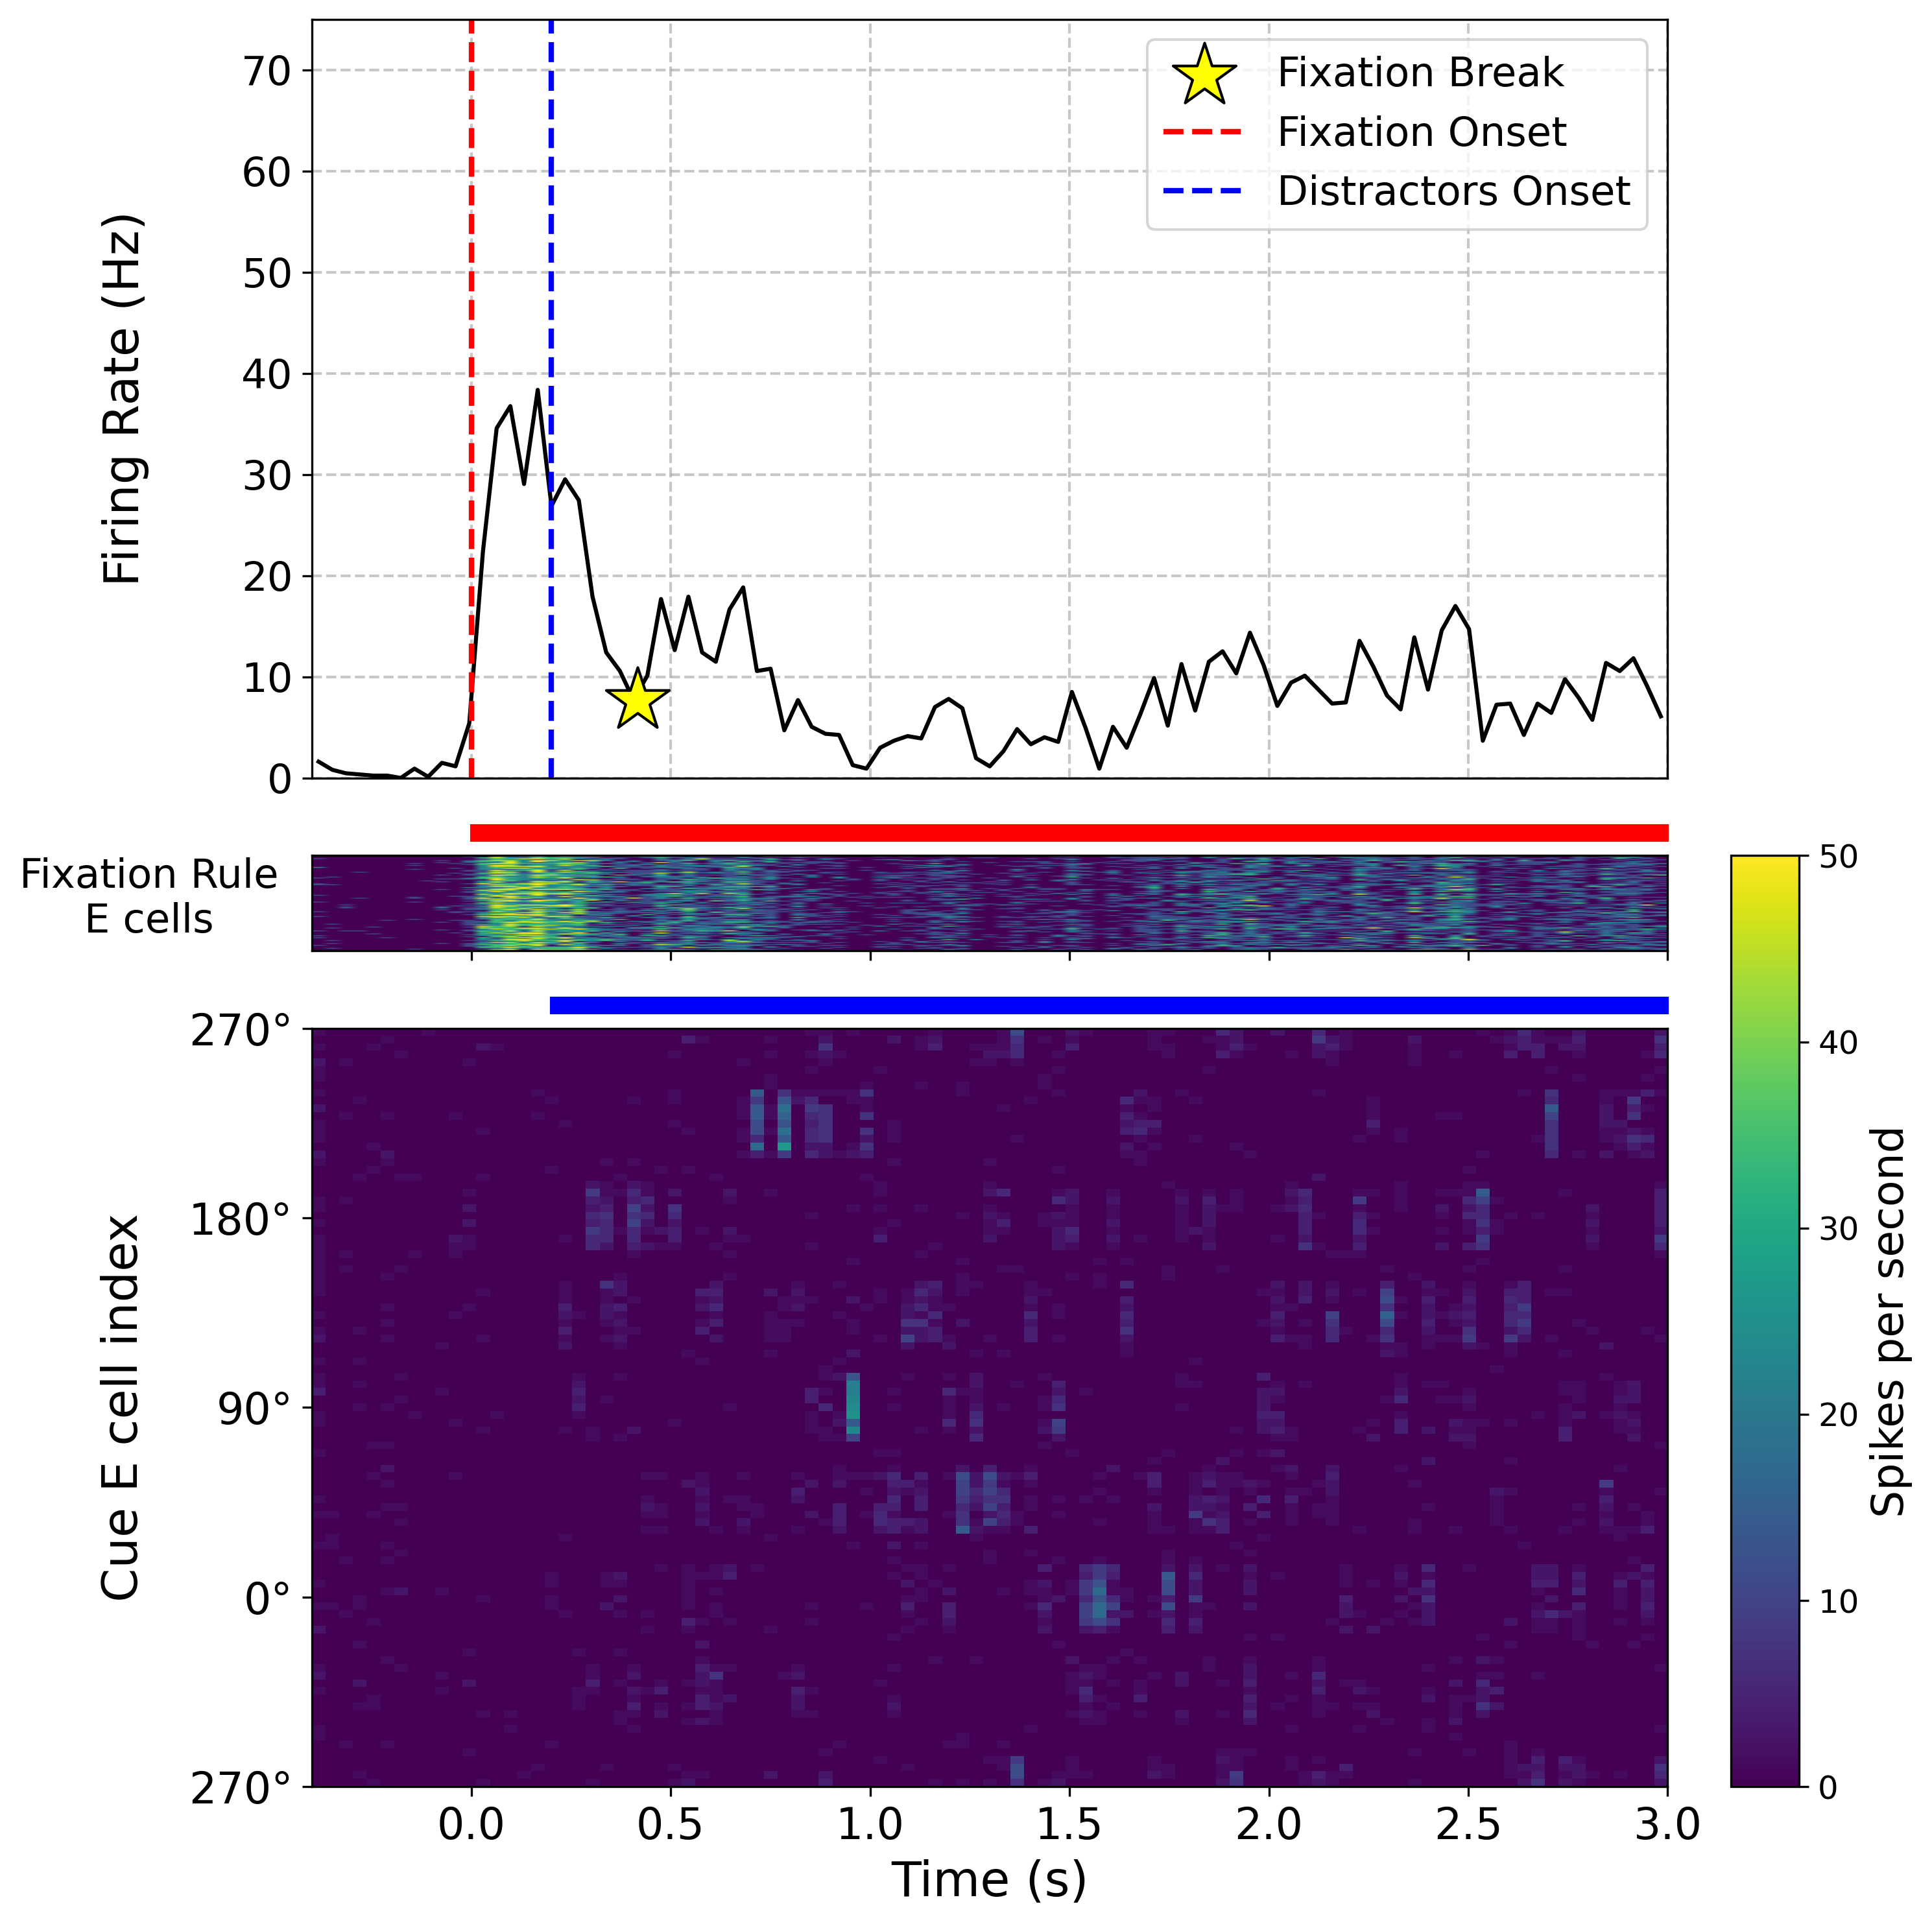

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

# # Load the data files
# data1 = numpy.load(f"{OUTPUT_DIR}/spike_monitor_excit_data_simulation.npz")
# data2 = numpy.load(f"{OUTPUT_DIR}/spike_monitor_fix_excit_data_simulation.npz")

# Extract data for the first plot (EXCITATORY population rastergram)
neuron_indices1 = numpy.asarray(spike_indices_excit) #data1['indices']
spike_times1 = numpy.asarray(spike_times_excit) #spike_times_excit #data1['times']
num_neurons1 = N_excitatory #neuron_indices1.max() + 1
neuron_degrees1 = neuron_indices1 * (360.0 / num_neurons1)

# Extract data for the second plot (FIXATION EXCITATORY population rastergram)
neuron_indices2 = numpy.asarray(spike_indices_fix_excit) #data2['indices_fix']
spike_times2 = numpy.asarray(spike_times_fix_excit) #spike_times_fix_excit #data2['times_fix']
num_neurons2 = N_fix_excitatory #neuron_indices2.max() + 1

# Define common time bins for both plots
time_start = 0
time_end = 3.4
bins_time = numpy.linspace(time_start, time_end, 100)

# Histogram calculations for the first plot
bins_neuron1 = numpy.linspace(0, 360, 100)
counts1, _, _ = numpy.histogram2d(spike_times1, neuron_degrees1, bins=[bins_time, bins_neuron1])
time_bin_duration = bins_time[1] - bins_time[0]
neurons_per_bin1 = num_neurons1 / 100
counts_per_second_per_neuron1 = counts1 / (time_bin_duration * neurons_per_bin1)

# Histogram calculations for the second plot
bins_neuron2 = numpy.linspace(0, num_neurons2, 100)
counts2, _, _ = numpy.histogram2d(spike_times2, neuron_indices2, bins=[bins_time, bins_neuron2])
neurons_per_bin2 = num_neurons2 / 100
counts_per_second_per_neuron2 = counts2 / (time_bin_duration * neurons_per_bin2)

# Average firing rate for the top plot
average_firing_rate = counts_per_second_per_neuron2.mean(axis=1)

# Convert time bins to centers for plotting
time_centers_fix = bins_time[:-1] + time_bin_duration / 2

# Find the first point where the average firing rate drops below 10 Hz after 0.6 seconds
valid_indices = numpy.where(time_centers_fix > 0.6)[0]
below_10_idx = numpy.where(average_firing_rate[valid_indices] < 10)[0]

if len(below_10_idx) > 0:
    first_below_10_idx = valid_indices[below_10_idx[0]]
    star_x = time_centers_fix[first_below_10_idx]
    star_y = average_firing_rate[first_below_10_idx]

# Create the figure and GridSpec layout
fig = plt.figure(figsize=(10, 10), dpi=300)
gs = GridSpec(3, 2, height_ratios=[1, 0.125, 1], width_ratios=[1, 0.05])

# Top plot (Average Firing Rate, now first)
ax_top = fig.add_subplot(gs[0, 0])
ax_top.plot(time_centers_fix, average_firing_rate, color="black")
ax_top.set_ylabel("Firing Rate (Hz)", fontsize=18, labelpad=10)
ax_top.yaxis.set_label_coords(-0.12, 0.5)  # Align with other plots
ax_top.set_xlim(time_start, time_end)
ax_top.set_ylim(0, 75)
ax_top.tick_params(axis="both", which="major", labelsize=15, bottom=False, labelbottom=False)  # Remove tick labels
ax_top.set_xticks(numpy.arange(0.4, 3.5, 0.5))
ax_top.grid(visible=True, which="both", linestyle="--", linewidth=1, alpha=0.7)

# Add the yellow star if the point was found
if len(below_10_idx) > 0:
    ax_top.scatter(star_x + 0.01, star_y, color='yellow', s=600, marker='*', edgecolor='black', zorder=10, label='Fixation Break')

# Vertical lines and updated legend for top plot
ax_top.axvline(x=0.4, color="red", linestyle="--", linewidth=2, label="Fixation Onset")
ax_top.axvline(x=0.6, color="blue", linestyle="--", linewidth=2, label="Distractors Onset")
ax_top.legend(fontsize=15)

# Middle plot (Fixation Rule E cells, now second)
ax_middle = fig.add_subplot(gs[1, 0])
img2 = ax_middle.imshow(
    counts_per_second_per_neuron2.T,
    extent=[time_start, time_end, 0, num_neurons2],
    aspect="auto",
    origin="lower",
    cmap="viridis",
    norm=Normalize(vmin=0, vmax=50)
)
ax_middle.set_ylabel("Fixation Rule\nE cells", fontsize=15, rotation=0, labelpad=20)
ax_middle.yaxis.set_label_coords(-0.12, 0.1)  # Move the label further to the left
ax_middle.set_yticks([])
ax_middle.tick_params(axis="both", which="major", labelsize=16, bottom=True, labelbottom=False)
ax_middle.set_xlim([time_start, time_end])
ax_middle.set_xticks(numpy.arange(0.4, 3.5, 0.5))
plt.setp(ax_middle.get_xticklabels(), visible=False)

# Bottom plot (Cue E cells, now third)
ax_bottom = fig.add_subplot(gs[2, 0], sharex=ax_middle)
img1 = ax_bottom.imshow(
    counts_per_second_per_neuron1.T,
    extent=[time_start, time_end, 270, 630],
    aspect="auto",
    origin="lower",
    cmap="viridis",
    norm=Normalize(vmin=0, vmax=50)
)
ax_bottom.set_ylabel("Cue E cell index", fontsize=18, labelpad=15)
ax_bottom.yaxis.set_major_locator(FixedLocator([270, 360, 450, 540, 630]))
ax_bottom.yaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: f"{val - 360:.0f}°" if val >= 360 else f"{val:.0f}°")
)
ax_bottom.tick_params(axis="both", which="major", labelsize=16, bottom=True, labelbottom=True)  # Add tick labels
ax_bottom.set_xlim([time_start, time_end])
ax_bottom.set_xticks(numpy.arange(0.4, 3.5, 0.5))
tick_labels = [f"{t - 0.4:.1f}" for t in numpy.arange(0.4, 3.5, 0.5)]
ax_bottom.set_xticklabels(tick_labels)
ax_bottom.set_xlabel("Time (s)", fontsize=18)  # Add x-axis label to the bottom plot

# Adding the blue line above the bottom plot (Cue E cells)
ax_bottom.axvspan(
    0.6, 3.4,
    ymin=1.02, ymax=1.04,
    color="blue",
    transform=ax_bottom.get_xaxis_transform(),
    clip_on=False
)

# Adjusting red bar's position above the middle plot
pos_middle = ax_middle.get_position()
pos_bottom = ax_bottom.get_position()

# Compute the offset and height of the axvspan for the middle plot
offset_middle = (1.02 - 1.0) * pos_bottom.height  # Offset based on bottom height
height_axvspan_middle = (1.04 - 1.02) * pos_bottom.height  # Height based on bottom height

# Compute red bar's position for the middle plot
axvspan_ymin_middle = pos_middle.y1 + offset_middle
axvspan_ymax_middle = axvspan_ymin_middle + height_axvspan_middle

# Adjust to axes fraction coordinates for ax_middle
axes_fraction_ymin_middle = (axvspan_ymin_middle - pos_middle.y0) / pos_middle.height
axes_fraction_ymax_middle = (axvspan_ymax_middle - pos_middle.y0) / pos_middle.height

# Adding the red line to the middle plot
ax_middle.axvspan(
    0.4, 3.4,
    ymin=axes_fraction_ymin_middle,
    ymax=axes_fraction_ymax_middle,
    color="red",
    transform=ax_middle.get_xaxis_transform(),
    clip_on=False
)

# Add a shared colorbar only for the last two plots (middle and bottom)
cax = fig.add_subplot(gs[1:, 1])  # Limited to rows for middle and bottom plots
cbar = fig.colorbar(img1, cax=cax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Spikes per second", size=16)

plt.tight_layout()
plt.show()